# Set Up

In [ ]:
#load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from nilearn import image, surface
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, chi2
import pingouin as pg
import glob
import seaborn as sns

from utils import annotate_regression_corr_bayes,plot_vwfa_data

In [ ]:
#set directories
project_dir = os.chdir('..')
df_dir = f'{project_dir}data/DFs/'
fig_dir=f'{project_dir}figures/'

#set variables
ROIs = ['VWFA1','VWFA2']
axes = ['X', 'Y', 'Z']

# set color palette
# Define your color palettes for each ROI
dysGroup_palette_VWFA1 = {'dys': '#BBF451', 'typ': '#05DF72'}
dysGroup_palette_VWFA2 = {'dys': '#53EAFD', 'typ': '#0097b2'} 


# Plot & Analyze


VWFA1
X
dys: -20.633, 5.218
typ: -19.312, 5.397
t(44.98)=-0.920 (p=0.3625; CI=(-4.21, 1.57))
Y
dys: -65.589, 8.281
typ: -66.510, 7.597
t(49.40)=0.435 (p=0.6654; CI=(-3.33, 5.17))
Z
dys: -43.129, 3.213
typ: -43.289, 3.676
t(41.44)=0.169 (p=0.8665; CI=(-1.75, 2.07))

VWFA2
X
dys: -26.641, 4.061
typ: -23.718, 4.814
t(39.20)=-2.308 (p=0.0264; CI=(-5.48, -0.36))
Y
dys: -42.981, 11.665
typ: -39.876, 11.795
t(44.34)=-0.947 (p=0.3488; CI=(-9.71, 3.50))
Z
dys: -50.071, 6.584
typ: -52.695, 5.704
t(49.20)=1.551 (p=0.1273; CI=(-0.78, 6.02))


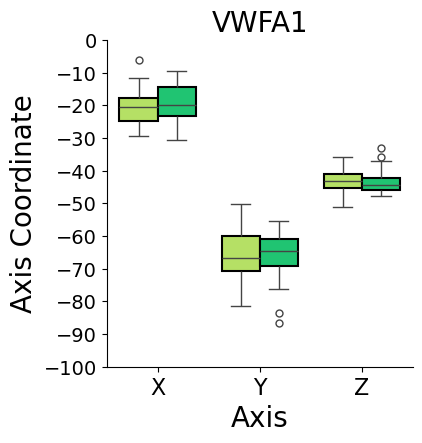

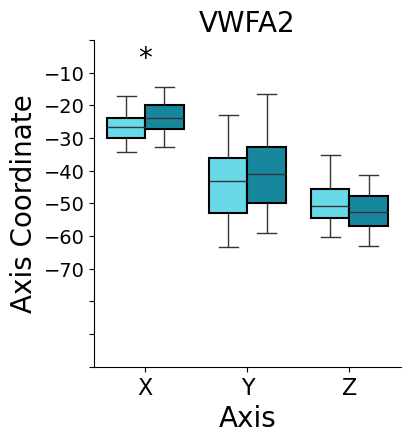

In [ ]:
# Set to True if you want to save the figure
save_fig = True

#read in data and pivot long
df = pd.read_csv(f'{df_dir}coords.csv')

df_long = df.melt(id_vars=['sub','hemi','roi','dys_group','wj_brs'],
                 value_vars=axes,
                 var_name='axis',
                  value_name='coord')

# ROI labels and legend labels
legend_labels = ['Dyslexic', 'Typical']

for roi in ROIs:
    print(f'\n{roi}')
    
    # Select palette based on ROI
    if roi == 'VWFA1':
        current_palette = dysGroup_palette_VWFA1
    elif roi == 'VWFA2':
        current_palette = dysGroup_palette_VWFA2
    
    # Get sizes for each ROI and group
    roi_df = df_long.query('roi==@roi')
    dys_df = roi_df.query('dys_group=="dys"')
    typ_df = roi_df.query('dys_group=="typ"')
    
    # Calculate p-values for significance using t-tests
    p_values = []
    t_values=[]
    DOFs=[]
    CIs=[]
    avg_sizes=[]
    for axis in axes:

        # run test
        results = ttest_ind(dys_df.query('axis==@axis')['coord'],
                                  typ_df.query('axis==@axis')['coord'],
                                  equal_var=False)

        # grab results
        t = results.statistic
        p = results.pvalue
        DOF = results.df
        CI = results.confidence_interval()

        #append results
        t_values.append(t)
        p_values.append(p)
        DOFs.append(DOF)
        CIs.append(CI)

        #Calculate bayes factor
        bf10 = pg.bayesfactor_ttest(
            t=t,
            nx=len(dys_df.query('axis==@axis')['coord']),
            ny=len(typ_df.query('axis==@axis')['coord']),
            paired=False,
            alternative='two-sided',
            r=0.707
        )
        bf01 = 1 / bf10

        print(axis)
        print(f"dys: {np.mean(dys_df.query('axis==@axis')['coord']):.3f}, {np.std(dys_df.query('axis==@axis')['coord']):.3f}")
        print(f"typ: {np.mean(typ_df.query('axis==@axis')['coord']):.3f}, {np.std(typ_df.query('axis==@axis')['coord']):.3f}")
        print(f't({DOF:.2f})={t:.3f} (p={p:.4f}; CI=({CI.low:.2f}, {CI.high:.2f}))')
        print(f'bf01 = {bf01:.3f}')

    # Plot the data
    g = sns.catplot(x='axis', y='coord', hue='dys_group', hue_order=['dys', 'typ'], data=roi_df, kind='box', palette=list(current_palette.values()),height=4, aspect=1,width=0.75)
    g.set_axis_labels("Axis", f"Axis Coordinate", size=20)
    g.set_xticklabels(size=16)
    g.set_yticklabels(size=14)
    plt.yticks(np.arange(-100, 1, 10))
    plt.title(roi,size=20)
    plt.ylim(-100,0)

    # Add borders to the boxes
    for ax in g.axes.flat:
        for box in ax.patches:
            box.set_edgecolor('black')  
            box.set_linewidth(1.5)      

    # Remove the original legend
    g._legend.remove()

    # Add significance indicators
    for i, p in enumerate(p_values):
        significance = ''
        if pd.notna(p):
            if p < 0.001:
                significance = '***'
            elif p < 0.01:
                significance = '**'
            elif p < 0.05:
                significance = '*'
            elif p >= 0.05:
                significance = ''
        if significance:
            # Position the text above the highest box for the given ROI
            y_max = -10
            if np.isfinite(y_max):  
                ax = g.axes.flat[0]
                ax.text(i, y_max + 0.1, significance, ha='center', va='bottom', fontsize=20, color='black')

    # Save the figure
    if save_fig:
        plt.savefig(f'{fig_dir}{roi}_coord_box.png', bbox_inches="tight", dpi=400)

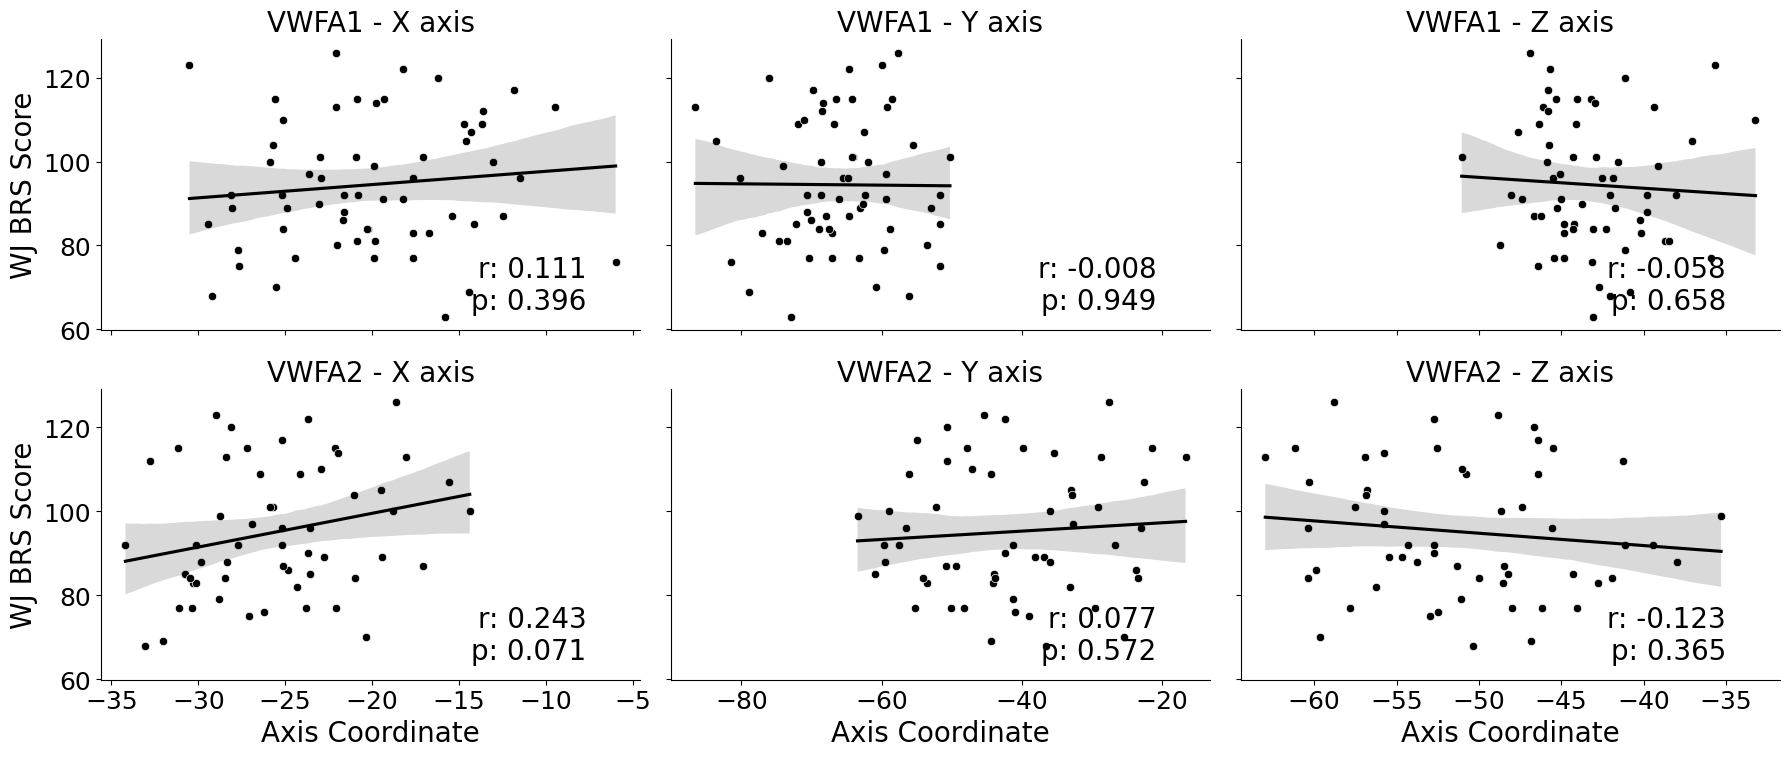

In [ ]:
# Set to True if you want to save the figure
save_fig = True


# Define assessment titles
titles = {
    'wj_brs': 'WJ BRS'
}

dysGroup_palette = {
    'dys': '#8E44AD',
    'typ': '#BB8FCE'}

#define variables
assessments = ['wj_brs']
rois = ['VWFA1','VWFA2']


# Create a FacetGrid
g = sns.FacetGrid(df_long, row='roi', col='axis', 
                  height=4, 
                  aspect=1.5, 
                  palette=list(dysGroup_palette.values()),
                 sharex='col')

# Map the scatterplot and regplot onto the FacetGrid
g.map(sns.scatterplot, 'coord', 'wj_brs', color='black')
g.map(sns.regplot, 'coord', 'wj_brs', scatter=False, color='black')

# Apply the annotation function to each subplot
g.map_dataframe(annotate_regression_corr_bayes,x_param='coord',y_param='wj_brs')

# Set uniform x and y-axis labels
g.set_axis_labels('Axis Coordinate', 'WJ BRS Score', size=20)

# Iterate through the axes and set the tick label font size
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=18)

# Set titles and labels for each subplot
for i, roi in enumerate(rois):
    for j, my_axis in enumerate(axes):
        ax = g.axes[i,j]
        ax.set_title(f'{roi} - {my_axis} axis', size=20)

# Adjust layout to ensure labels are visible
plt.tight_layout(rect=[0, 0, 1, 0.96])

if save_fig:
    g.savefig(f'{fig_dir}coordsXscores.png', bbox_inches="tight", dpi=400)

plt.show()


# Plot spread of data

## Plot 95% Confidense Ellipsoids

VWFA1


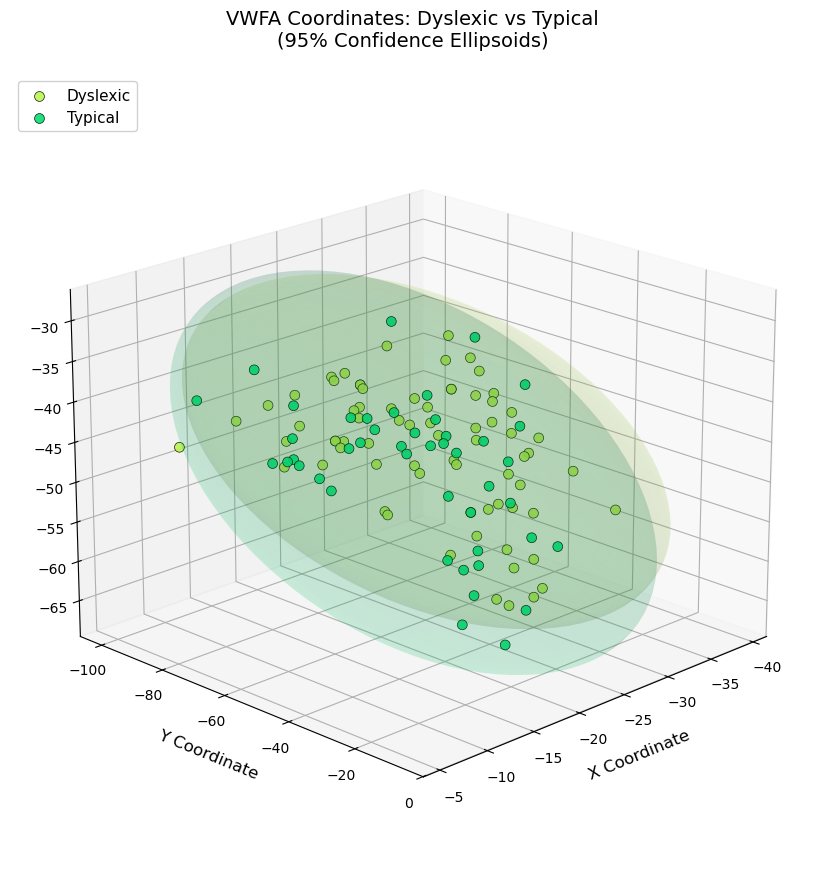

Total number of points: 61

Points per group:
dys_group
dys    38
typ    23
Name: count, dtype: int64
VWFA2


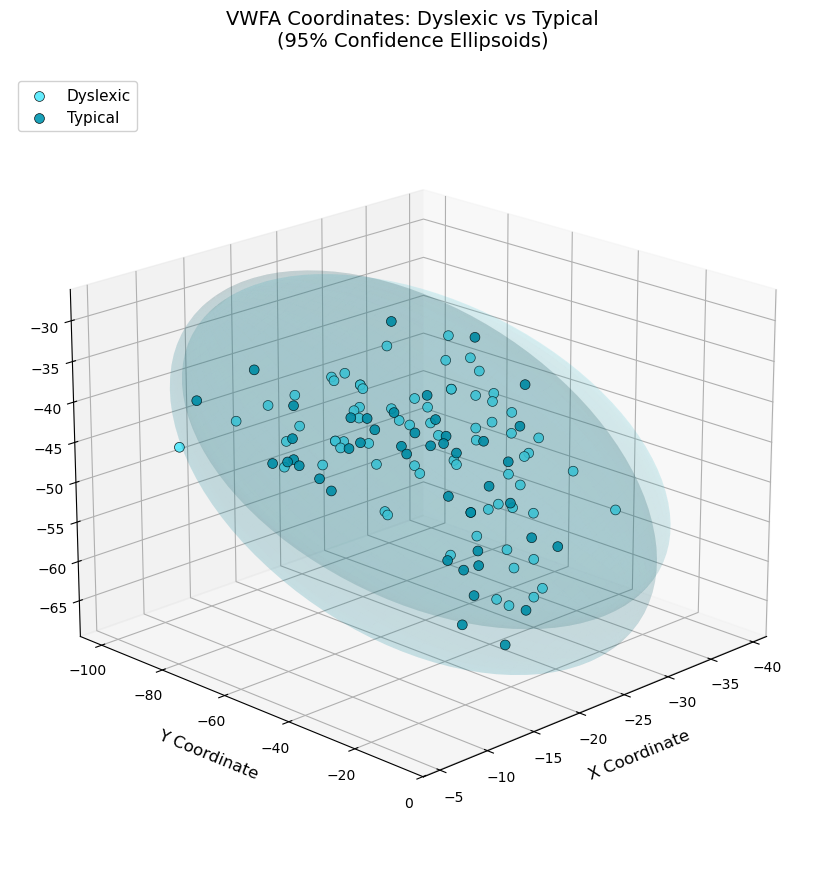

Total number of points: 56

Points per group:
dys_group
dys    34
typ    22
Name: count, dtype: int64


In [47]:
#flag to save figures
save_fig = False

# load data
df = pd.read_csv(f'{df_dir}coords.csv').query('hemi=="LH"')

plot_df = df.rename(columns={"X": "x", "Y": "y","Z":"z"})

#set color schemes for different ROIs
color_schemes = {
    'VWFA1': {
        'colors': {'dys': '#BBF451', 'typ': '#05DF72'},
        'labels': {'dys': 'Dyslexic', 'typ': 'Typical'}},
    'VWFA2': {
        'colors': {'dys': '#53EAFD', 'typ': '#0097b2'},
        'labels': {'dys': 'Dyslexic', 'typ': 'Typical'}}}

#loop through ROIs and plot
for roi in ROIs:
    vwfa_df = df.query('roi==@roi')
    print(roi)
    
    fig, ax = plot_vwfa_data(
        plot_df, 
        confidence=0.95,
        color_map=color_schemes[roi]['colors'],
        label_map=color_schemes[roi]['labels'],
        scatter_alpha = .9,
        ellipsoid_alpha = .1
    )
    ax.set_box_aspect(None, zoom=0.95) 
    plt.show()
    
    if save_fig:
        fig.savefig(f'{fig_dir}{roi}_ellipsoids.png', bbox_inches="tight", dpi=400)
    
    print(f"Total number of points: {len(vwfa_df)}")
    print(f"\nPoints per group:")
    print(vwfa_df['dys_group'].value_counts())

## Plot 2d 95% Confidence Ellipses 
### (to reference for results figure approximation)

In [20]:

def draw_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    
    # Scale and translate
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    # Apply transform
    import matplotlib.transforms as transforms
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
        
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)



VWFA1


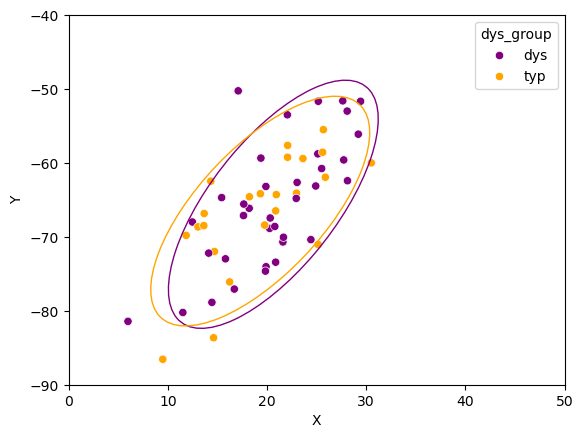

VWFA2


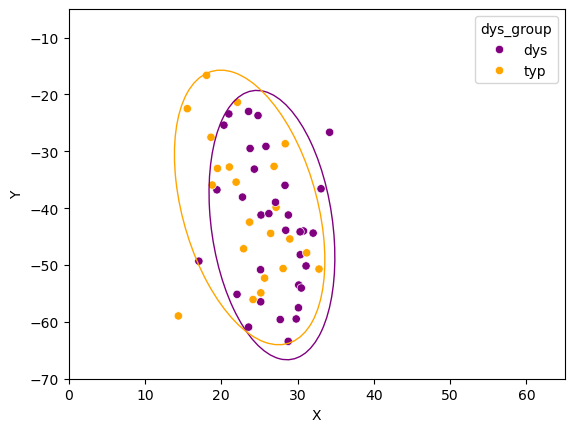

In [35]:
# define simple color palette
custom_colors = {"dys": "purple", "typ": "orange"}

#loop through rois to plot
for roi in ROIs:
    #subset the data
    vwfa_df = df.query('roi==@roi')
    
    #flip x sign  to correspond with image direction
    vwfa_df['X'] =  vwfa_df['X']*-1
   
    # plot
    print(roi)
    ax = sns.scatterplot(data=vwfa_df, x="X", y="Y",hue='dys_group', palette=custom_colors)
    draw_confidence_ellipse(vwfa_df.query('dys_group=="dys"')["X"].dropna(), 
                            vwfa_df.query('dys_group=="dys"')["Y"].dropna(), 
                            ax, n_std=2.0, facecolor='none', edgecolor=custom_colors['dys'])
    draw_confidence_ellipse(vwfa_df.query('dys_group=="typ"')["X"].dropna(), 
                            vwfa_df.query('dys_group=="typ"')["Y"].dropna(), 
                            ax, n_std=2.0, facecolor='none', edgecolor=custom_colors['typ'])
    # specify axis limits for ease
    if roi=="VWFA1":
        plt.ylim((-90,-40))
        plt.xlim((0,50))
    elif roi=="VWFA2":
        plt.ylim((-70,-5))
        plt.xlim((0,65))
    plt.show()